In [1]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar

In [2]:
# 2008-2020 MetOp-A Data (constant orbit)
# seasonal trends and min and max
# NIGHT and night

In [3]:
# compute monhtly means and stack them
lst_2008 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2008/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [4]:
lst_2009 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2009/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [5]:
lst_2010 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2010/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [6]:
lst_2011 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2011/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [7]:
lst_2012 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2012/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [8]:
lst_2013 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2013/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [9]:
lst_2014 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2014/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [10]:
lst_2015 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2015/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [11]:
lst_2016 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2016/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [12]:
lst_2017 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2017/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [13]:
lst_2018 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2018/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [14]:
lst_2019 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2019/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [15]:
lst_2020 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2020/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [16]:
# load the time series somewhere ?
results = {}

for year in range(2008, 2021):

    ds = globals()[f"lst_{year}"]   # load lst_1981, lst_1982, ...

    clean_LST = ds['LST'].where(ds['LST'] > 110, np.nan)
    monthly_mean = (
        clean_LST
        .resample(
            time='1MS'
        )
        .mean()
    )

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

    results[year] = monthly_mean

combined = xr.concat([results[y] for y in range(2008, 2021)], dim="time")

In [17]:
climatology = combined.groupby('time.season').mean("time")

In [18]:
# compute trends
winter = combined.sel(time=combined.time.dt.month.isin([1,2, 12]))

In [19]:
winter['time']= winter['time'] + np.timedelta64(10000000000000000, 'ns')

In [20]:
winter_data = winter.groupby('time.year').mean()

In [22]:
winter_data = winter_data.chunk({'year':-1, 'lon':1000, 'lat':100})

In [23]:
winter_night_trends = xr.open_dataset('winter_trend.nc')

In [24]:
winter_night_trends

<xarray.Dataset> Size: 46MB
Dimensions:      (lat: 800, lon: 7200)
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    band         int64 8B ...
    spatial_ref  int64 8B ...
    time         datetime64[ns] 8B ...
Data variables:
    trend        (lat, lon) float64 46MB ...

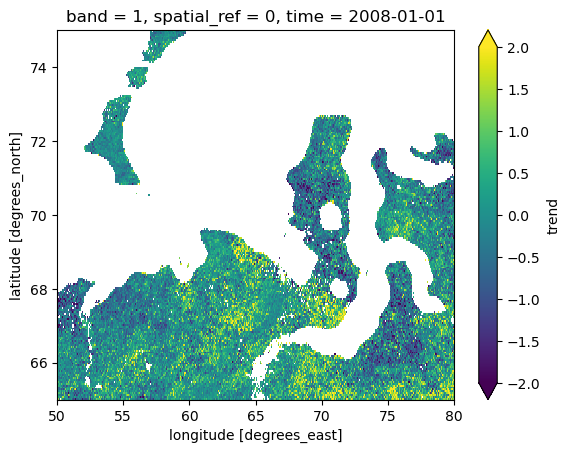

In [28]:
winter_night_trends['trend'].sel(lat=slice(65,75), lon=slice(50,80)).plot(vmin=-2, vmax=2);

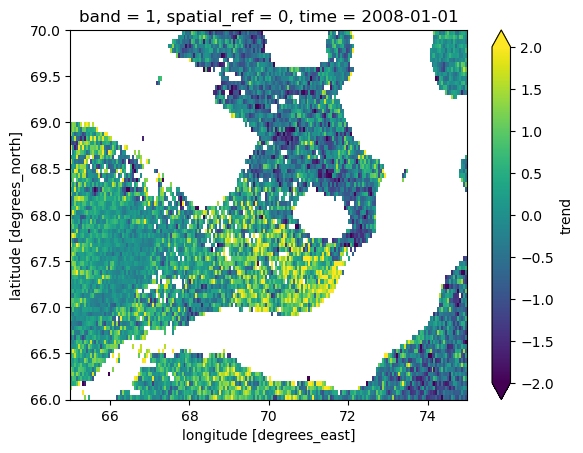

In [29]:
winter_night_trends['trend'].sel(lat=slice(66,70), lon=slice(65,75)).plot(vmin=-2, vmax=2);

In [33]:
float(winter_night_trends['trend'].sel(lat=67.5, lon=71, method='nearest'))

2.154583333333332

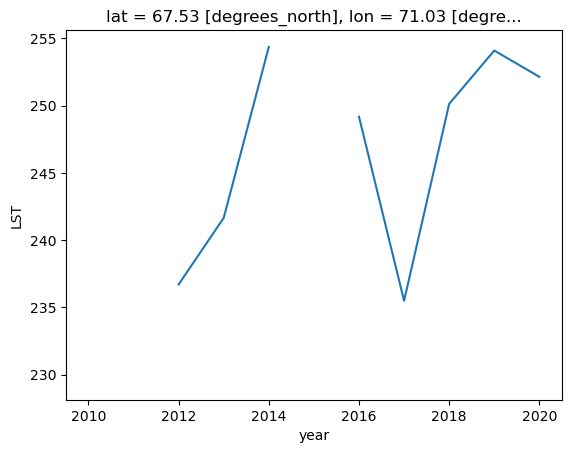

In [36]:
winter_data.sel(lat=67.5, lon=71, method='nearest').plot();

In [38]:
winter_data.sel(lat=67.5, lon=71, method='nearest').values

array([         nan,          nan, 229.385     ,          nan,
       236.7       , 241.65      , 254.355     ,          nan,
       249.165     , 235.48833333, 250.12      , 254.085     ,
       252.135     ,          nan])

In [ ]:
mk.original_test(Birth_data_holes, alpha=0.05)